# Exploratory Data Analysis — Player Performance Dataset

This notebook performs EDA on `new-players-data-full.csv`.

Sections: Load data, missing values, distributions, correlations, positional comparisons, value analysis, and top players.

## 1) Load data and inspect

Load the CSV, show shape, dtypes and the first few rows.

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
pd.options.display.max_columns = 200
DATA_PATH = os.path.join('..', 'data', 'new-players-data-full.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
df.head()

Shape: (18773, 74)

Dtypes:
player_slug       object
version           object
name              object
full_name         object
description       object
                   ...  
gk_handling        int64
gk_kicking         int64
gk_positioning     int64
gk_reflexes        int64
play_styles       object
Length: 74, dtype: object


,player_slug,version,name,full_name,description,image,height_cm,weight_kg,dob,positions,best_position,overall_rating,potential,value,wage,preferred_foot,weak_foot,skill_moves,international_reputation,body_type,real_face,release_clause,specialities,club_id,club_name,club_league_id,club_league_name,club_logo,club_position,club_kit_number,club_joined,club_contract_valid_until,country_id,country_name,country_league_id,country_league_name,country_flag,country_position,country_kit_number,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,play_styles
0,rodrigo-hernandez-cascante,2025-07-17,Rodri,Rodrigo Hernández Cascante,Rodri (born 22 June 1996) is a Spanish footbal...,https://cdn.sofifa.net/players/231/866/25_120.png,190,82,1996-06-22,"CDM,CM",CDM,91,91,€115.5M,€440K,Right,4,3,5,Normal (185+),Yes,€213.7M,Distance shooter,10.0,Manchester City,13.0,Premier League,https://cdn.sofifa.net/meta/team/9/30.png,RES,16.0,2019-07-04,2027,1362.0,Spain,78.0,Friendly International,https://cdn.sofifa.net/meta/team/18710/30.png,RES,16.0,76,74,81,93,71,84,86,64,91,90,65,66,66,93,67,92,83,91,83,89,85,84,76,84,62,94,92,87,82,10,10,7,14,8,"Tiki Taka +,Power Shot,Long Ball Pass,Bruiser,..."
1,mohamed-salah,2025-07-17,Mohamed Salah Hamed Ghaly,Mohamed Salah Hamed Ghalyمحمد صلاح,"Mohamed Salah (Mohamed Salah Hamed Ghaly, born...",https://cdn.sofifa.net/players/209/331/25_120.png,175,72,1992-06-15,"RM,RW",RM,91,91,€104M,€350K,Left,3,4,5,Unique,Yes,€192.4M,"Dribbler,Crosser,Acrobat,Clinical finisher,Com...",9.0,Liverpool,13.0,Premier League,https://cdn.sofifa.net/meta/team/8/30.png,RM,11.0,2017-07-01,2027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86,95,59,88,83,90,88,69,81,90,89,89,89,94,91,83,79,88,75,84,63,55,93,89,87,93,38,43,41,14,14,9,11,14,"Finesse Shot +,Chip Shot,Pinged Pass,Whipped C..."
2,jude-bellingham,2025-07-17,Jude Victor William Bellingham,Jude Victor William Bellingham,Jude Bellingham (Jude Victor William Bellingha...,https://cdn.sofifa.net/players/252/371/25_120.png,186,75,2003-06-29,"CAM,CM",CAM,90,94,€174.5M,€280K,Right,4,4,5,Normal (170-185),Yes,€370.8M,"Dribbler,Playmaker,Clinical finisher,Complete ...",243.0,Real Madrid,53.0,La Liga,https://cdn.sofifa.net/meta/team/3468/30.png,RCM,5.0,2023-07-01,2029,1318.0,England,78.0,Friendly International,https://cdn.sofifa.net/meta/team/18645/30.png,CAM,10.0,66,89,75,90,77,89,73,68,89,89,81,80,82,91,79,85,85,93,80,86,85,82,91,91,74,87,77,79,77,14,11,10,5,8,"Relentless +,Intercept,Slide Tackle,Technical,..."
3,erling-haaland,2025-07-17,Erling Braut Håland,Erling Braut Håland,"Erling Haaland (Erling Braut Håland, born 21 J...",https://cdn.sofifa.net/players/239/085/25_120.png,195,94,2000-07-21,ST,ST,90,92,€157M,€270K,Left,3,3,5,Unique,Yes,€302.2M,"Aerial threat,Distance shooter,Strength,Clinic...",10.0,Manchester City,13.0,Premier League,https://cdn.sofifa.net/meta/team/9/30.png,SUB,9.0,2022-07-01,2034,1352.0,Norway,78.0,Friendly International,https://cdn.sofifa.net/meta/team/18578/30.png,ST,9.0,58,96,83,77,90,79,77,62,66,83,80,94,77,93,69,94,92,76,93,83,88,43,95,74,90,88,38,47,29,7,14,13,11,7,"Chip Shot +,Power Shot,Power Header,Bruiser,Pr..."
4,vinicius-jose-de-oliveira-junior,2025-07-17,Vini Jr.,Vinicius José Paixão de Oliveira Junior,Vini Jr. (Vinicius José Paixão de Oliveira Jun...,https://cdn.sofifa.net/players/238/794/25_120.png,176,73,2000-07-12,"LW,ST",CAM,90,94,€171.5M,€340K,Right,4,5,5,Lean (170-185),Yes,€364.4M,"Speedster,Dribbler,Acrobat,Clinical finisher,C...",243.0,Real Madrid,53.0,La Liga,https://cdn.sofifa.net/meta/team/3468/30.png,LW,7.0,2018-07-12,2027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81,89,50,83,73,93,79,62,77,90,95,95,94,86,84,81,74,84,65,83,58,26,87,85,74,83,32,25,

**Insights:**

- Review the printed `shape` and `dtypes` to confirm column types.
- If numeric columns are parsed as objects (strings), convert them before analysis.

## 2) Missing values heatmap

Visualise missing data per column (percentage) using a heatmap.

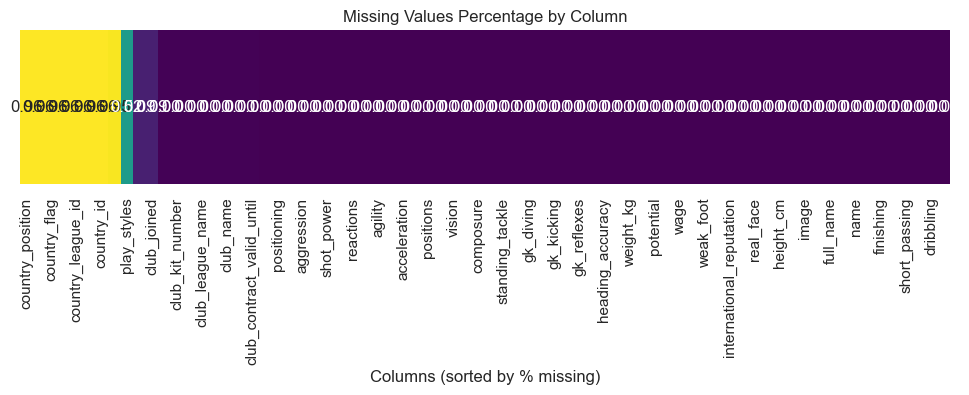

In [20]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(12, 2))
sns.heatmap(missing_pct.to_frame().T, cmap='viridis', annot=True, fmt='.2f', cbar=False)
plt.yticks([])
plt.xlabel('Columns (sorted by % missing)')
plt.title('Missing Values Percentage by Column')
plt.show()

**Insights:**

- Columns with high missingness (e.g. `play_styles`) may need special handling (imputation or dropped for some analyses).
- Consider dropping columns with extremely high missing rates or engineering indicators for missingness.

## 3) Distribution of `overall_rating`

Plot the distribution and summary statistics for the target variable `overall_rating`.

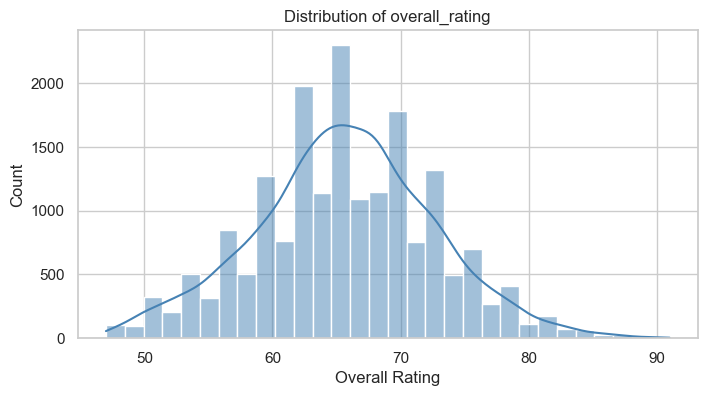

count    18773.000000
mean        65.623555
std          7.042377
min         47.000000
25%         61.000000
50%         66.000000
75%         70.000000
max         91.000000
Name: overall_rating, dtype: float64

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(df['overall_rating'].dropna(), kde=True, bins=30, color='steelblue')
plt.title('Distribution of overall_rating')
plt.xlabel('Overall Rating')
plt.ylabel('Count')
plt.show()

# Summary statistics
(df['overall_rating'].describe())

**Insights:**

- Check skewness and whether ratings cluster around certain bands (e.g., 60-80).
- If distribution is heavily skewed, consider stratified modelling or transformations for certain analyses.

## 4) Top 10 features correlating with `overall_rating`

Compute correlations and show a heatmap for the top features most correlated (positive or negative) with the target.

In [22]:
# Compute correlations (numeric columns only)
numeric = df.select_dtypes(include=[np.number])
corr_with_target = numeric.corr()['overall_rating'].abs().sort_values(ascending=False)
top_features = corr_with_target.drop('overall_rating').head(10).index.tolist()
top_features

['reactions',
 'composure',
 'potential',
 'jumping',
 'shot_power',
 'vision',
 'short_passing',
 'long_passing',
 'ball_control',
 'international_reputation']

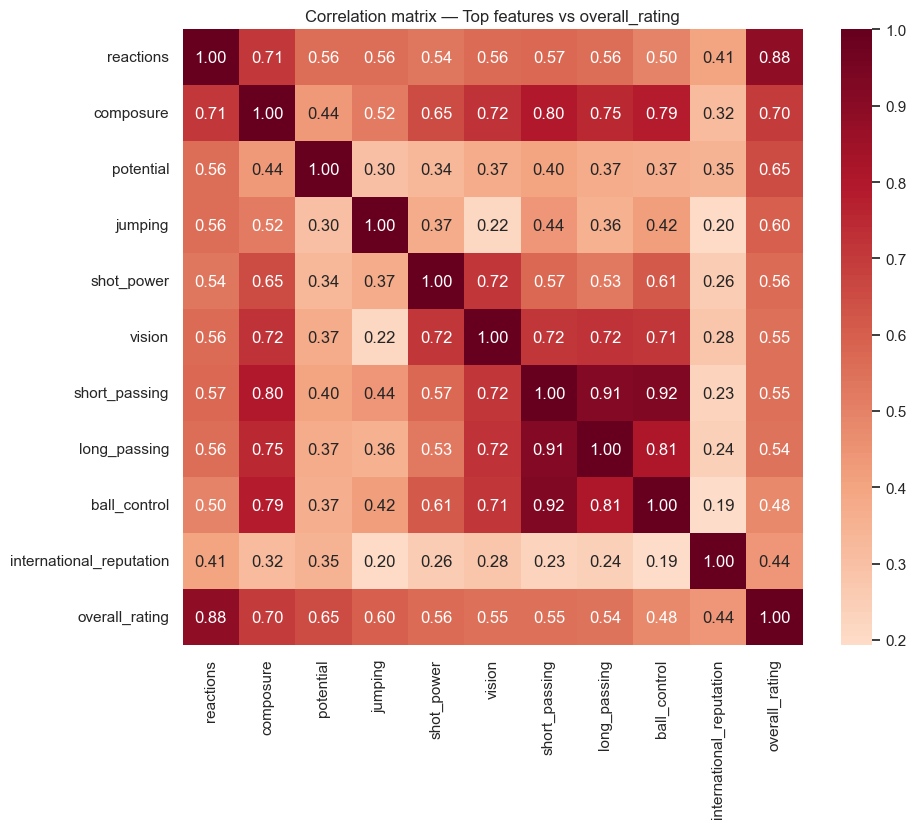

In [23]:
# Correlation matrix for the top features + target
cols = top_features + ['overall_rating']
plt.figure(figsize=(10,8))
sns.heatmap(numeric[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation matrix — Top features vs overall_rating')
plt.show()

**Insights:**

- The heatmap shows which physical/technical attributes most closely track `overall_rating`.
- Use these features for baseline models or feature selection.

## 5) Average `overall_rating` by `best_position`

Compare average ratings across positions — filter to positions with enough samples to be meaningful.

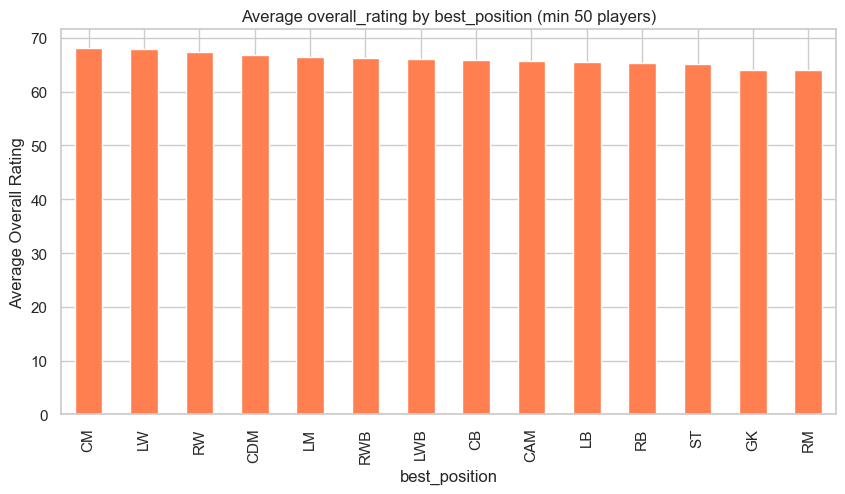

best_position
CM     68.150086
LW     68.000000
RW     67.307377
CDM    66.849388
LM     66.370328
RWB    66.247748
LWB    66.127962
CB     65.855200
CAM    65.626006
LB     65.586598
RB     65.394140
ST     65.121418
GK     64.038992
RM     64.034437
Name: overall_rating, dtype: float64

In [24]:
pos_counts = df['best_position'].value_counts(dropna=True)
min_count = 50
valid_positions = pos_counts[pos_counts >= min_count].index
pos_mean = df[df['best_position'].isin(valid_positions)].groupby('best_position')['overall_rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
pos_mean.plot(kind='bar', color='coral')
plt.ylabel('Average Overall Rating')
plt.title(f'Average overall_rating by best_position (min {min_count} players)')
plt.show()
pos_mean

**Insights:**

- Positions with higher average ratings may be specialized (e.g., central attackers or elite goalkeepers).
- Consider position as a strong predictor and possibly build position-specific models.

## 6) `value` vs `overall_rating` scatter plot

Visualise the relationship between market `value` and player `overall_rating` (robust parsing included).

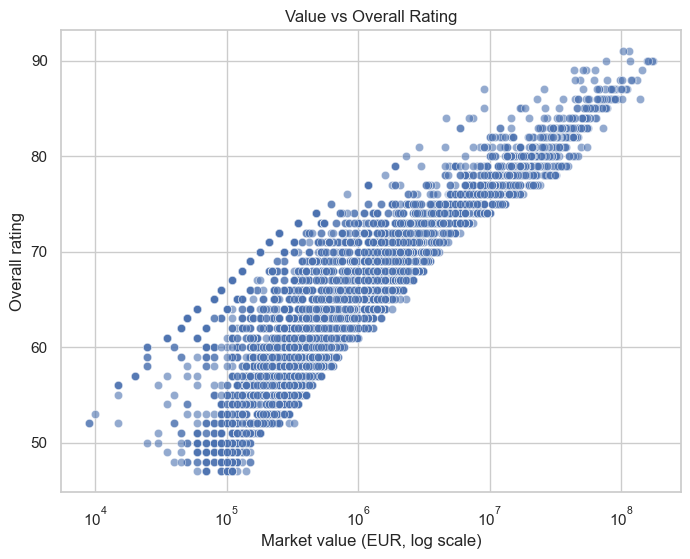

In [25]:
import re

def parse_money(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).replace('€', '').replace(',', '').strip()
    # Handle K and M suffixes
    m = re.match(r'([0-9\.]+)\s*([KMkm]?)', s)
    if not m:
        try:
            return float(s)
        except ValueError:
            return np.nan
    val, suf = m.groups()
    val = float(val)
    if suf.upper() == 'M':
        return val * 1e6
    if suf.upper() == 'K':
        return val * 1e3
    return val

# Create numeric value column if present
if 'value' in df.columns:
    df['value_eur'] = df['value'].apply(parse_money)
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x='value_eur', y='overall_rating', alpha=0.6)
    plt.xscale('log')
    plt.xlabel('Market value (EUR, log scale)')
    plt.ylabel('Overall rating')
    plt.title('Value vs Overall Rating')
    plt.show()
else:
    print('\nColumn `value` not found in the dataset.')

**Insights:**

- Using a log scale for `value` helps visualise market differences across ratings.
- Expect a positive trend but with many outliers (expensive younger prospects or low-rated high-value contracts).

## 7) Top 20 highest rated players

Show the player names and `overall_rating` for the top 20 players. The notebook will try common name columns.

,name,overall_rating
0,Rodri,91
1,Mohamed Salah Hamed Ghaly,91
2,Jude Victor William Bellingham,90
3,Erling Braut Håland,90
4,Vini Jr.,90
5,Kylian Mbappé Lottin,90
6,Virgil van Dijk,90
7,Harry Edward Kane,90
8,Thibaut Nicolas Marc Courtois,89
9,Robert Lewandowski,89


C:\Users\User\AppData\Local\Temp\ipykernel_13364\3485725205.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x='overall_rating', y=name_col, palette='magma')


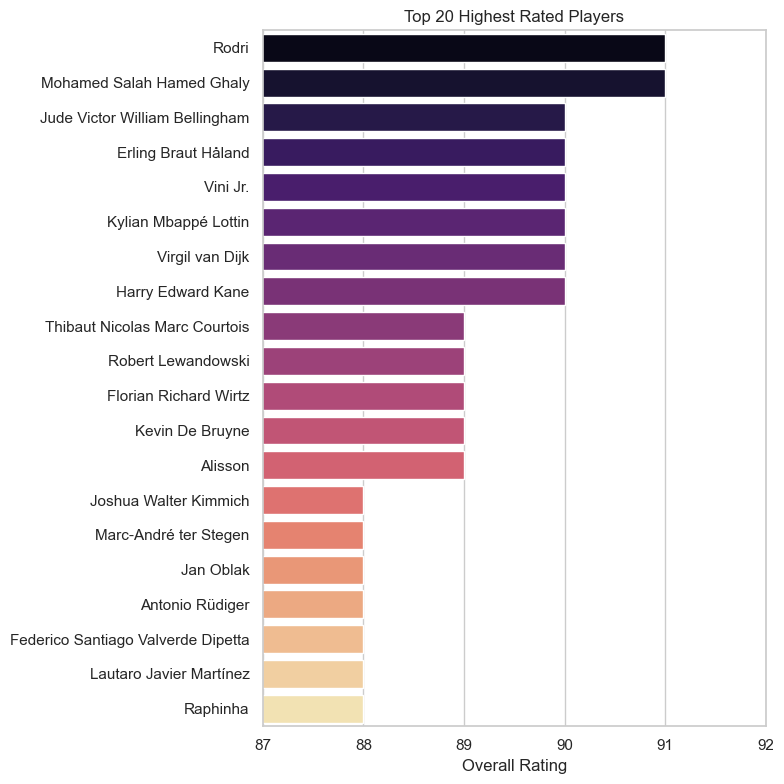

In [26]:
from IPython.display import display

possible_name_cols = ['short_name', 'player_name', 'name', 'long_name']
name_col = next((c for c in possible_name_cols if c in df.columns), None)
if name_col is None:
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    name_col = non_numeric[0] if non_numeric else None

if name_col is not None and 'overall_rating' in df.columns:
    top20 = (
        df.dropna(subset=['overall_rating'])
          .sort_values(['overall_rating'], ascending=False)
          [[name_col, 'overall_rating']]
          .head(20)
          .reset_index(drop=True)
    )
    display(top20)

    plt.figure(figsize=(8,8))
    sns.barplot(data=top20, x='overall_rating', y=name_col, palette='magma')
    plt.title('Top 20 Highest Rated Players')
    plt.xlabel('Overall Rating')
    plt.ylabel('')
    plt.xlim(top20['overall_rating'].min() - 1, top20['overall_rating'].max() + 1)
    plt.tight_layout()
    plt.show()
else:
    print('No name-like column found or `overall_rating` missing in the dataset.')

**Insights:**

- The top players list is useful for sanity checks and manual validation.
- If names are missing, inspect non-numeric columns for appropriate identifiers.